## Subagents 

A deep agent can create subagent to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent's context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long running tasks, parallel workstreams or cases where you need mid-flight steering and acncellationsee Async subagents. 

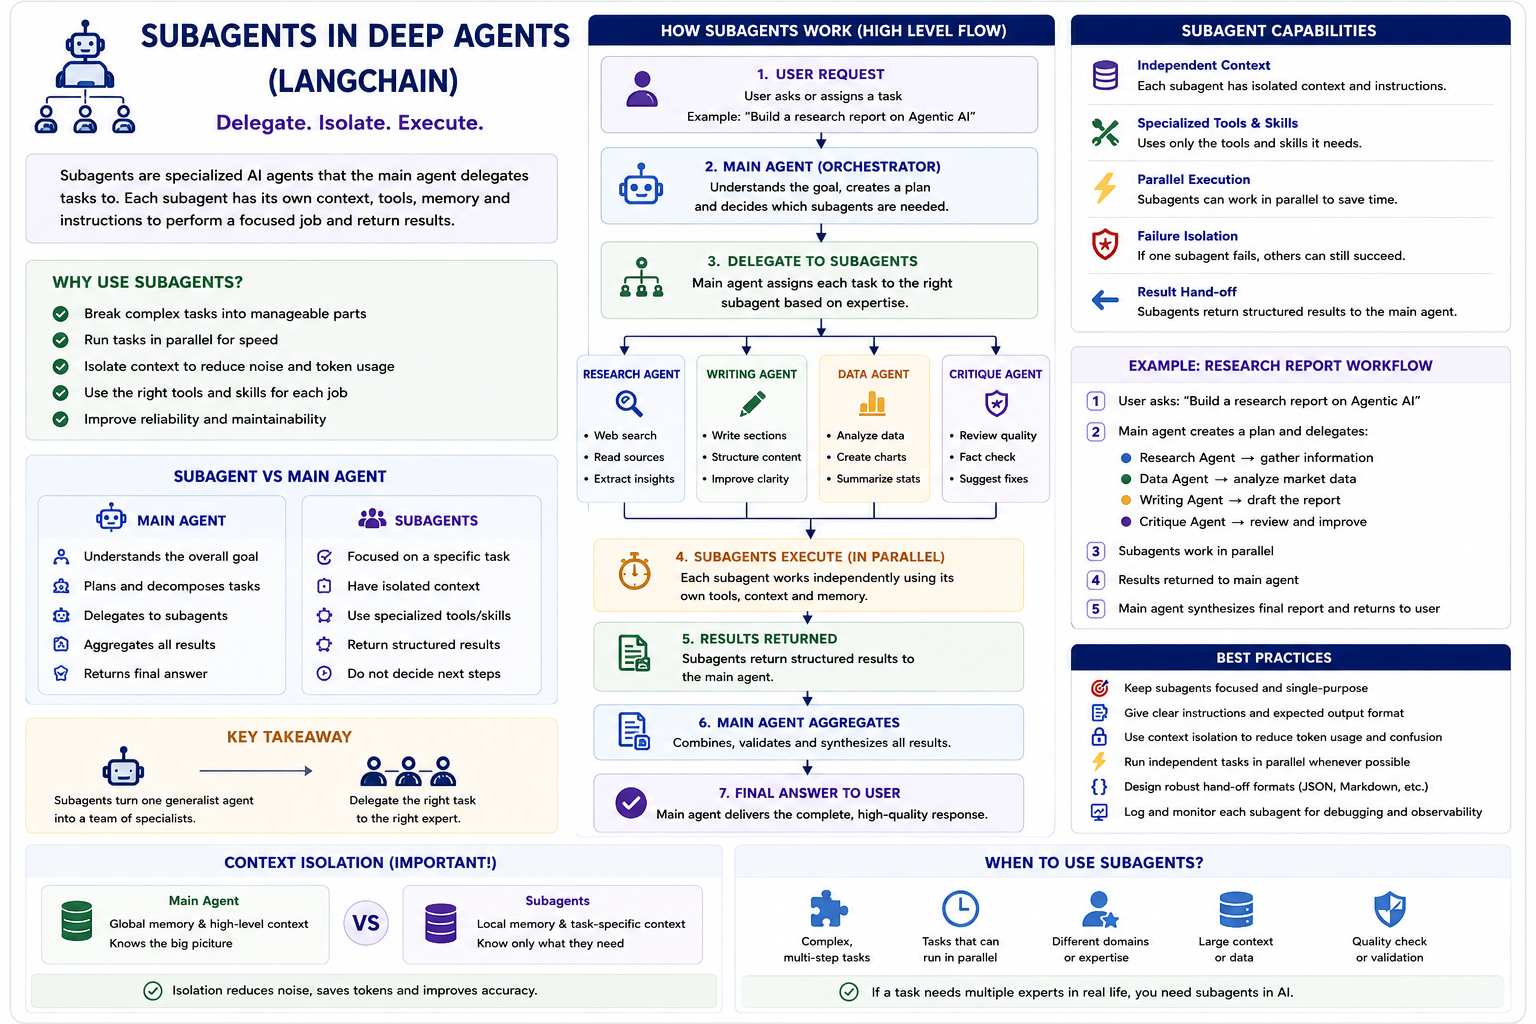

In [1]:
import os 
from dotenv import load_dotenv 
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

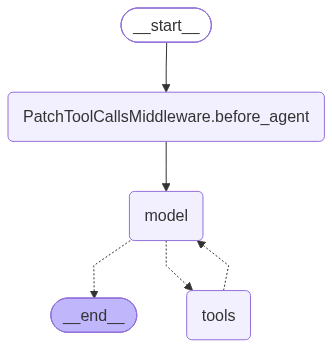

In [9]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


def internet_search(
        query: str, 
        max_results : int = 5, 
        topic: Literal["general", "news", "finance"] = "general", 
        include_raw_content: bool = False 
) : 
    """Run a web search"""
    return tavily_client.search(
        query, 
        max_results=max_results, 
        include_raw_content=include_raw_content, 
        topic = topic, 
    )


research_subagent = {
    "name": "research_agent", 
    "description": "Used to research more in depth questions", 
    "system_prompt": "You are a great researcher", 
    "tools": [internet_search], 
    "model": "groq:qwen/qwen3.6-27b", 
}

subagents = [research_subagent]

agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b",  
    subagents = subagents
)

agent 

In [3]:
results = agent.invoke(
    {
        "messages": [{
            "role": "user", 
            "content": "Research about LLM Gateways and provide me a detailed summary"
        }], 
    }, 
    config = {"configurable": {"thread_id": "skills-demo-2"}}
)

#print the conversation so you can SEE the skill being triggered 
# Look for a ToolMessage form 'read_file' on the langgraph docs SKILL.md 
for m in results["messages"]: 
    m.pretty_print()

================================ Human Message =================================

Research about LLM Gateways and provide me a detailed summary
================================== Ai Message ==================================
Tool Calls:
  task (11dwkggpk)
 Call ID: 11dwkggpk
  Args:
    description: Research LLM Gateways thoroughly and provide a comprehensive summary covering:

1. Definition: What is an LLM Gateway?
2. Purpose and Benefits: Why use an LLM Gateway? What problems does it solve?
3. Key Features: Rate limiting, load balancing, caching, authentication, logging, monitoring, fallback mechanisms, model routing, etc.
4. Architecture: How does an LLM Gateway work? Where does it sit in the architecture?
5. Popular/Open Source Implementations: LiteLLM Proxy, Bearer, Portkey, LangGate, etc.
6. Use Cases: When and why would someone use an LLM Gateway?
7. Comparison: LLM Gateway vs. API Gateway vs. Service Mesh
8. Challenges and Considerations: What are the trade-offs?

Provide detai

### Structured Ouput with Sub Agents 

In [12]:
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq


class ResearchFindings(BaseModel):
    """Structured findings from a research task"""

    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")


model = ChatGroq(
    model="openai/gpt-oss-120b",
    max_tokens=1500
)


research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly and return the findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}


agent = create_deep_agent(
    model=model,
    subagents=[research_subagent]
)


result = await agent.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Research recent advances in quantum computing"
            }
        ]
    }
)

In [13]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================

Below is a high‑level snapshot of the most noteworthy advances in quantum computing that have appeared **since roughly 2021** (the period covered by the latest literature up to mid‑2024).  I’ve grouped the progress into hardware platforms, error‑correction/benchmarking, algorithms & software, and ecosystem/industry developments, and I’ve highlighted a few key papers or announcements for each sub‑area so you can dig deeper if you wish.

---

## 1. Hardware Platforms – “What the Qubits Are Made Of”

| Platform | Recent Milestones (2022‑2024) | Why It Matters |
|----------|------------------------------|----------------|
| **Superconducting qubits** (IBM, Google, Rigetti, Alibaba) | • **IBM “Eagle” (127‑qubit) processor (2022)** and **Condor (1,121‑qubit) roadmap (2023‑2025)** – mod